# 🌍 War Economic Impact Analysis (Global Conflicts)

# Project Overview
This project presents an end-to-end Data Analysis of the War Economic Impact dataset using Python. The main objective is to analyze how wars and conflicts affect economic conditions across different countries and regions.

The project focuses on understanding the impact of conflicts on GDP, unemployment, poverty, inflation, currency stability, black market activities, and reconstruction costs through Exploratory Data Analysis (EDA) and data visualization.

This project demonstrates the complete Data Analytics workflow including data cleaning, preprocessing, outlier detection, exploratory analysis, and business insight generation.

# Project Workflow
1. Data Collection

- Imported War Economic Impact dataset
- Loaded dataset using Pandas

3. Data Cleaning
- Performed following data cleaning steps
- Checked dataset information
- Verified column names
- Checked missing values
- Removed duplicate records
- Corrected data types
- Prepared dataset for analysis

3. Data Preprocessing
- Performed:
- Missing value handling
- Duplicate removal
- Data type conversion
- Feature preparation
- Numerical and categorical data validation

4. Data Quality Checks

-Performed:
- Duplicate Detection
- Missing Value Analysis
- Data Type ValidationOutlier Detection using statistical methods and visualization

In [198]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [199]:
df = pd.read_csv("war_economic_impact_dataset.csv")
pd.set_option('display.max_row', None)
pd.set_option('display.max_columns', None)
df.head()

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,Most_Affected_Sector,Youth_Unemployment_Change_%,Pre_War_Poverty_Rate_%,During_War_Poverty_Rate_%,Extreme_Poverty_Rate_%,Food_Insecurity_Rate_%,Households_Fallen_Into_Poverty_Estimate,GDP_Change_%,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented
0,WWII (Japan),World War,East Asia,1939,1945,Resolved,Japan,7.49,21.78,14.29,Construction,19.90,19.97,28.67,10.39,15.00,38487,-36.86,97.41,170.33,1.069570e+11,2.090550e+11,15.50,27.09,High,food,10.50,No
1,Israel-Hamas War,Asymmetric War,Middle East,2023,2026,Ongoing,Palestine (Gaza),8.18,23.00,14.82,Tourism,19.92,8.49,18.93,8.45,12.92,166213,-64.99,73.68,41.97,3.041650e+11,5.859160e+11,11.95,34.76,Dominant,fuel,19.31,No
2,Syrian Civil War,Civil War,Middle East,2011,2026,Ongoing,Syria,12.70,36.46,23.76,Tourism,27.06,22.11,41.31,14.41,28.83,114129,-19.03,69.35,53.91,4.848230e+11,1.666740e+12,38.18,90.00,Moderate,"water, weapons, currency",298.95,No
3,WWII (Germany),World War,Europe,1939,1945,Resolved,Germany,14.06,17.83,3.77,Construction,4.44,6.13,8.87,4.04,5.40,1916,-42.29,36.92,48.51,7.132119e+10,2.500160e+11,12.24,36.42,Moderate,"currency, medicine, weapons",15.44,No
4,Afghanistan War,Interstate/Counter-insurgency,South Asia,2001,2021,Resolved,Afghanistan,5.38,5.98,0.59,Construction,0.85,22.67,23.27,14.16,12.33,4111,-43.84,52.62,31.32,1.561800e+11,3.612380e+11,31.89,74.86,Dominant,medicine,443.61,Yes


In [50]:
df.tail()

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,Most_Affected_Sector,Youth_Unemployment_Change_%,Pre_War_Poverty_Rate_%,During_War_Poverty_Rate_%,Extreme_Poverty_Rate_%,Food_Insecurity_Rate_%,Households_Fallen_Into_Poverty_Estimate,GDP_Change_%,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented
99995,Afghanistan War,Interstate/Counter-insurgency,South Asia,2001,2021,Resolved,Afghanistan,4.76,6.39,1.64,Energy,1.84,7.15,8.56,4.67,4.37,7116,-42.61,17.59,15.01,2.537390e+11,9.628950e+11,24.29,38.53,Dominant,"currency, water, weapons",0.16,Yes
99996,Israel-Iran War,Interstate War,Middle East,2025,2026,Ongoing,Iran,6.31,9.18,2.88,Tourism,3.70,8.14,9.90,5.95,8.71,101115,-24.69,29.05,40.53,4.424990e+11,8.123640e+11,23.63,52.81,Low,"weapons, currency",341.19,No
99997,Israel-Iran War,Interstate War,Middle East,2025,2026,Ongoing,Iran,9.21,24.93,15.71,Energy,19.78,13.42,29.67,11.86,20.19,52889,-43.99,44.44,88.01,8.074347e+10,1.925440e+11,28.69,60.65,Low,"food, weapons, fuel",139.88,Yes
99998,Israel-Hamas War,Asymmetric War,Middle East,2023,2026,Ongoing,Palestine (Gaza),7.67,13.25,5.58,Agriculture,7.04,8.81,15.35,7.25,11.20,29107,-66.86,17.16,12.25,3.100220e+11,1.123350e+12,22.96,47.43,Dominant,"water, medicine, weapons",18.20,Yes
99999,Tigray Conflict,Civil War,Africa,2020,2022,Resolved,Ethiopia,5.70,16.04,10.34,Services,14.86,26.67,32.34,10.24,25.95,982693,-34.88,96.06,128.06,1.498420e+11,2.552170e+11,25.48,44.35,High,"currency, medicine",5.59,No


In [52]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   Conflict_Name                            100000 non-null  object 
 1   Conflict_Type                            100000 non-null  object 
 2   Region                                   100000 non-null  object 
 3   Start_Year                               100000 non-null  int64  
 4   End_Year                                 100000 non-null  int64  
 5   Status                                   100000 non-null  object 
 6   Primary_Country                          100000 non-null  object 
 7   Pre_War_Unemployment_%                   100000 non-null  float64
 8   During_War_Unemployment_%                100000 non-null  float64
 9   Unemployment_Spike_Percentage_Points     100000 non-null  float64
 10  Most_Affected_Sector             

Conflict_Name                              0
Conflict_Type                              0
Region                                     0
Start_Year                                 0
End_Year                                   0
Status                                     0
Primary_Country                            0
Pre_War_Unemployment_%                     0
During_War_Unemployment_%                  0
Unemployment_Spike_Percentage_Points       0
Most_Affected_Sector                       0
Youth_Unemployment_Change_%                0
Pre_War_Poverty_Rate_%                     0
During_War_Poverty_Rate_%                  0
Extreme_Poverty_Rate_%                     0
Food_Insecurity_Rate_%                     0
Households_Fallen_Into_Poverty_Estimate    0
GDP_Change_%                               0
Inflation_Rate_%                           0
Currency_Devaluation_%                     0
Cost_of_War_USD                            0
Estimated_Reconstruction_Cost_USD          0
Informal_E

In [53]:
df.shape

(100000, 28)

In [ ]:
df = df.drop_duplicates().sum()

In [60]:
df.head()

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,Most_Affected_Sector,Youth_Unemployment_Change_%,Pre_War_Poverty_Rate_%,During_War_Poverty_Rate_%,Extreme_Poverty_Rate_%,Food_Insecurity_Rate_%,Households_Fallen_Into_Poverty_Estimate,GDP_Change_%,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented
0,WWII (Japan),World War,East Asia,1939,1945,Resolved,Japan,7.49,21.78,14.29,Construction,19.90,19.97,28.67,10.39,15.00,38487,-36.86,97.41,170.33,1.069570e+11,2.090550e+11,15.50,27.09,High,food,10.50,No
1,Israel-Hamas War,Asymmetric War,Middle East,2023,2026,Ongoing,Palestine (Gaza),8.18,23.00,14.82,Tourism,19.92,8.49,18.93,8.45,12.92,166213,-64.99,73.68,41.97,3.041650e+11,5.859160e+11,11.95,34.76,Dominant,fuel,19.31,No
2,Syrian Civil War,Civil War,Middle East,2011,2026,Ongoing,Syria,12.70,36.46,23.76,Tourism,27.06,22.11,41.31,14.41,28.83,114129,-19.03,69.35,53.91,4.848230e+11,1.666740e+12,38.18,90.00,Moderate,"water, weapons, currency",298.95,No
3,WWII (Germany),World War,Europe,1939,1945,Resolved,Germany,14.06,17.83,3.77,Construction,4.44,6.13,8.87,4.04,5.40,1916,-42.29,36.92,48.51,7.132119e+10,2.500160e+11,12.24,36.42,Moderate,"currency, medicine, weapons",15.44,No
4,Afghanistan War,Interstate/Counter-insurgency,South Asia,2001,2021,Resolved,Afghanistan,5.38,5.98,0.59,Construction,0.85,22.67,23.27,14.16,12.33,4111,-43.84,52.62,31.32,1.561800e+11,3.612380e+11,31.89,74.86,Dominant,medicine,443.61,Yes


In [59]:
df.shape

(100000, 28)

In [58]:
df.dtypes

Conflict_Name                               object
Conflict_Type                               object
Region                                      object
Start_Year                                   int64
End_Year                                     int64
Status                                      object
Primary_Country                             object
Pre_War_Unemployment_%                     float64
During_War_Unemployment_%                  float64
Unemployment_Spike_Percentage_Points       float64
Most_Affected_Sector                        object
Youth_Unemployment_Change_%                float64
Pre_War_Poverty_Rate_%                     float64
During_War_Poverty_Rate_%                  float64
Extreme_Poverty_Rate_%                     float64
Food_Insecurity_Rate_%                     float64
Households_Fallen_Into_Poverty_Estimate      int64
GDP_Change_%                               float64
Inflation_Rate_%                           float64
Currency_Devaluation_%         

In [57]:
df.describe()

,Start_Year,End_Year,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,Youth_Unemployment_Change_%,Pre_War_Poverty_Rate_%,During_War_Poverty_Rate_%,Extreme_Poverty_Rate_%,Food_Insecurity_Rate_%,Households_Fallen_Into_Poverty_Estimate,GDP_Change_%,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Currency_Black_Market_Rate_Gap_%
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000.000000
mean,1999.401340,2009.039940,9.017027,22.625199,13.608181,17.686763,17.518820,29.077185,14.553542,20.351211,1.597617e+05,-31.614770,69.945965,87.580570,2.507148e+11,6.895004e+11,25.002639,51.783920,126.181130
std,29.957153,30.552183,3.458406,13.818295,11.960175,15.678211,7.217439,13.000781,7.487060,9.790643,9.355617e+05,18.120243,35.045196,55.632842,1.436970e+11,4.471766e+11,8.648263,21.266786,156.324982
min,1939.000000,1945.000000,3.000000,3.360000,0.320000,0.360000,5.000000,5.400000,1.840000,3.100000,1.000000e+00,-85.000000,0.030000,0.030000,1.001111e+09,1.617224e+09,10.000000,12.140000,0.000000
25%,1996.000000,2011.000000,6.030000,12.780000,5.330000,6.860000,11.260000,20.030000,9.270000,13.490000,5.710750e+03,-42.210000,42.710000,45.110000,1.266235e+11,3.239365e+11,17.520000,34.420000,9.330000
50%,2011.000000,2026.000000,9.020000,19.480000,10.220000,13.245000,17.520000,27.630000,13.200000,18.800000,2.210450e+04,-29.700000,69.290000,76.680000,2.501850e+11,6.367630e+11,25.010000,49.190000,18.760000
75%,2022.000000,2026.000000,12.000000,28.800000,17.890000,23.270000,23.790000,35.290000,18.250000,25.200000,8.439800e+04,-17.337500,94.800000,120.460000,3.750452e+11,9.934735e+11,32.490000,67.820000,241.432500
max,2025.000000,2026.000000,15.000000,89.400000,74.470000,108.710000,30.000000,98.000000,68.490000,86.320000,9.928908e+07,-5.000000,295.560000,528.400000,4.999990e+11,1.997800e+12,40.000000,90.000000,500.000000


In [56]:
df.describe(include='all')

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,Most_Affected_Sector,Youth_Unemployment_Change_%,Pre_War_Poverty_Rate_%,During_War_Poverty_Rate_%,Extreme_Poverty_Rate_%,Food_Insecurity_Rate_%,Households_Fallen_Into_Poverty_Estimate,GDP_Change_%,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented
count,100000,100000,100000,100000.000000,100000.000000,100000,100000,100000.000000,100000.000000,100000.000000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,1.000000e+05,1.000000e+05,100000.000000,100000.000000,100000,100000,100000.000000,100000
unique,11,5,5,NaN,NaN,2,13,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,156,NaN,2
top,Israel-Hamas War,Civil War,Middle East,NaN,NaN,Ongoing,Germany,NaN,NaN,NaN,Construction,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,food,NaN,Yes
freq,9197,36142,45408,NaN,NaN,54478,9169,NaN,NaN,NaN,16871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25377,5634,NaN,69974
mean,NaN,NaN,NaN,1999.401340,2009.039940,NaN,NaN,9.017027,22.625199,13.608181,NaN,17.686763,17.518820,29.077185,14.553542,20.351211,1.597617e+05,-31.614770,69.945965,87.580570,2.507148e+11,6.895004e+11,25.002639,51.783920,NaN,NaN,126.181130,NaN
std,NaN,NaN,NaN,29.957153,30.552183,NaN,NaN,3.458406,13.818295,11.960175,NaN,15.678211,7.217439,13.000781,7.487060,9.790643,9.355617e+05,18.120243,35.045196,55.632842,1.436970e+11,4.471766e+11,8.648263,21.266786,NaN,NaN,156.324982,NaN
min,NaN,NaN,NaN,1939.000000,1945.000000,NaN,NaN,3.000000,3.360000,0.320000,NaN,0.360000,5.000000,5.400000,1.840000,3.100000,1.000000e+00,-85.000000,0.030000,0.030000,1.001111e+09,1.617224e+09,10.000000,12.140000,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,1996.000000,2011.000000,NaN,NaN,6.030000,12.780000,5.330000,NaN,6.860000,11.260000,20.030000,9.270000,13.490000,5.710750e+03,-42.210000,42.710000,45.110000,1.266235e+11,3.239365e+11,17.520000,34.420000,NaN,NaN,9.330000,NaN
50%,NaN,NaN,NaN,2011.000000,2026.000000,NaN,NaN,9.020000,19.480000,10.220000,NaN,13.245000,17.520000,27.630000,13.200000,18.800000,2.210450e+04,-29.700000,69.290000,76.680000,2.501850e+11,6.367630e+11,25.010000,49.190000,NaN,NaN,18.760000,NaN
75%,NaN,NaN,NaN,2022.000000,2026.000000,NaN,NaN,12.000000,28.800000,17.890000,NaN,23.270000,23.790000,35.290000,18.250000,25.200000,8.439800e+04,-17.337500,94.800000,120.460000,3.750452e+11,9.934735e+11,32.490000,67.820000,NaN,NaN,241.432500,NaN


In [55]:
df.nunique()

Conflict_Name                                 11
Conflict_Type                                  5
Region                                         5
Start_Year                                    10
End_Year                                       5
Status                                         2
Primary_Country                               13
Pre_War_Unemployment_%                      1201
During_War_Unemployment_%                   7188
Unemployment_Spike_Percentage_Points        6226
Most_Affected_Sector                           6
Youth_Unemployment_Change_%                 7786
Pre_War_Poverty_Rate_%                      2501
During_War_Poverty_Rate_%                   7116
Extreme_Poverty_Rate_%                      4432
Food_Insecurity_Rate_%                      5568
Households_Fallen_Into_Poverty_Estimate    62109
GDP_Change_%                                6933
Inflation_Rate_%                           15512
Currency_Devaluation_%                     21993
Cost_of_War_USD     

In [27]:
#df.value_counts()

In [28]:
#df.unique()

In [54]:
df.duplicated().sum()

np.int64(0)

In [61]:
df.columns

Index(['Conflict_Name', 'Conflict_Type', 'Region', 'Start_Year', 'End_Year',
       'Status', 'Primary_Country', 'Pre_War_Unemployment_%',
       'During_War_Unemployment_%', 'Unemployment_Spike_Percentage_Points',
       'Most_Affected_Sector', 'Youth_Unemployment_Change_%',
       'Pre_War_Poverty_Rate_%', 'During_War_Poverty_Rate_%',
       'Extreme_Poverty_Rate_%', 'Food_Insecurity_Rate_%',
       'Households_Fallen_Into_Poverty_Estimate', 'GDP_Change_%',
       'Inflation_Rate_%', 'Currency_Devaluation_%', 'Cost_of_War_USD',
       'Estimated_Reconstruction_Cost_USD', 'Informal_Economy_Size_Pre_War_%',
       'Informal_Economy_Size_During_War_%', 'Black_Market_Activity_Level',
       'Primary_Black_Market_Goods', 'Currency_Black_Market_Rate_Gap_%',
       'War_Profiteering_Documented'],
      dtype='object')

**Ques 1.** Use a histogram with a KDE (Kernel Density Estimate) to visualize the distribution of GDP_Change_% across all recorded conflicts. What does the skewness tell you about the economic impact of war?

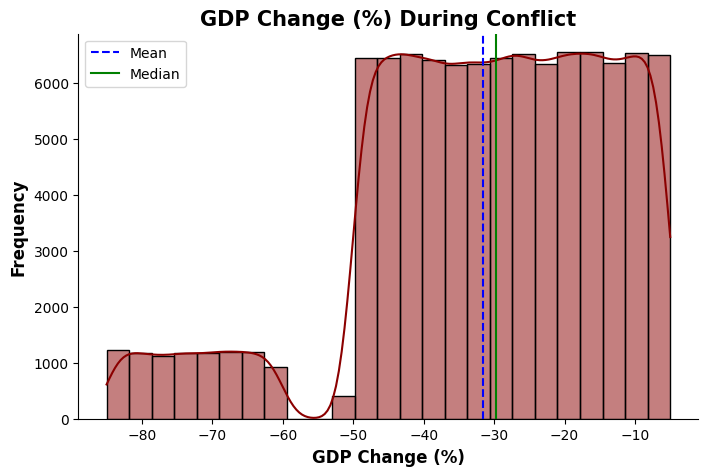

In [85]:
plt.figure(figsize=(8,5))
sns.histplot(
    data = df,
    x = "GDP_Change_%",
    bins = 25,
    kde = True,
    color = 'darkred',
    edgecolor="black"
)
plt.axvline(df["GDP_Change_%"].mean(), color='blue', linestyle='--', label='Mean')
plt.axvline(df["GDP_Change_%"].median(), color='green', linestyle='-', label='Median')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title("GDP Change (%) During Conflict", color = 'Black', fontsize = 15,fontweight = 'bold')
plt.xlabel("GDP Change (%)", color = 'Black', fontweight = 'bold', fontsize = 12)
plt.ylabel("Frequency",color = 'Black', fontweight = 'bold', fontsize = 12)
plt.legend()
plt.show()

**Question 2:** Create a bar chart showing the average Inflation_Rate_% for each Region. Which region typically experiences the highest inflation during conflict?

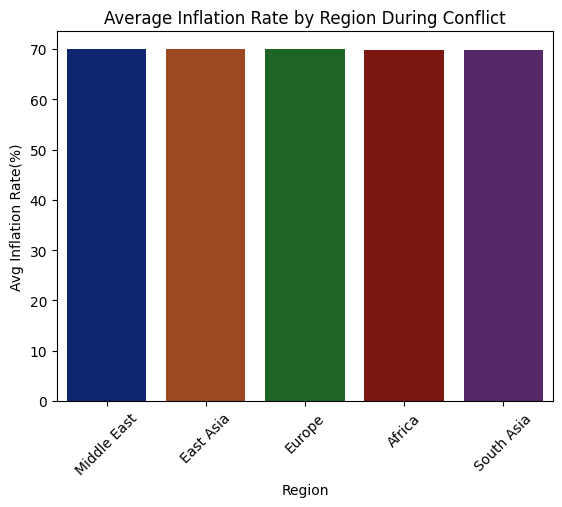

In [113]:
region_inflation = df.groupby('Region')["Inflation_Rate_%"].mean().sort_values(ascending = False).reset_index()

sns.barplot(
    data = region_inflation, 
    x =  'Region',
    y = 'Inflation_Rate_%',
    palette = 'dark',
    hue = 'Region'
)
plt.title('Average Inflation Rate by Region During Conflict')
plt.ylabel('Avg Inflation Rate(%)')
plt.xlabel('Region')
plt.xticks(rotation=45)
plt.show()

In [114]:
#df['Inflation_Rate_%'].mean()

In [110]:
print("Highest Inflation Region:", region_inflation.iloc[0]['Region'])

Highest Inflation Region: Middle East


In [116]:
print(region_inflation.head(1))

        Region  Inflation_Rate_%
0  Middle East         69.995181


**Question 3:** Generate a correlation heatmap for all numerical columns (Unemployment, Poverty, Inflation, Cost of War). Which two economic factors are most strongly correlated?

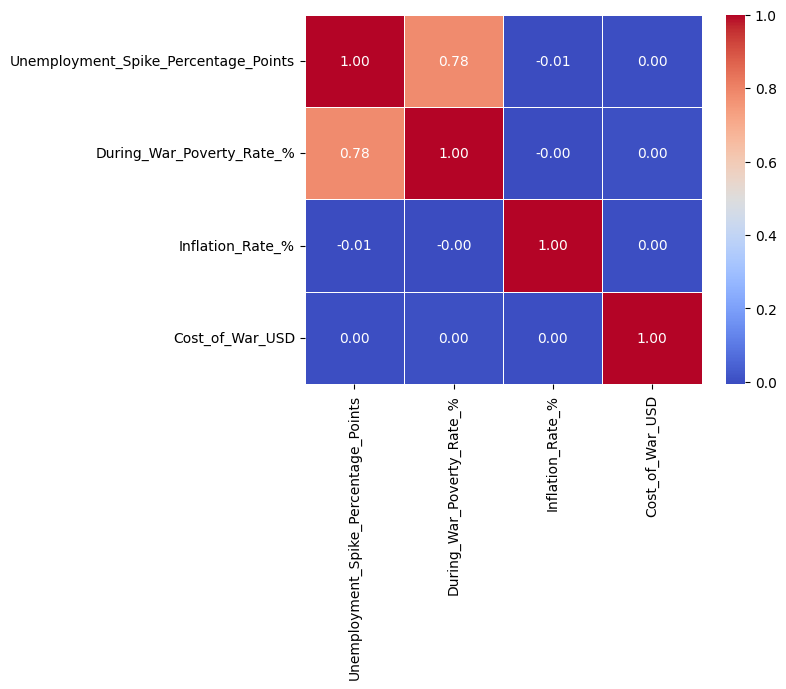

In [126]:
corr_data = df[['Unemployment_Spike_Percentage_Points',
                'During_War_Poverty_Rate_%',
                'Inflation_Rate_%',
                'Cost_of_War_USD'
    ]]
correlation_matrix = corr_data.corr()

sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f',
    linewidths=0.5
)
plt.show()

In [123]:
#df.columns

In [122]:
#df.head(1)

**Question 4:** Generate a correlation heatmap for all numerical columns (Unemployment, Poverty, Inflation, Cost of War). Which two economic factors are most strongly correlated?

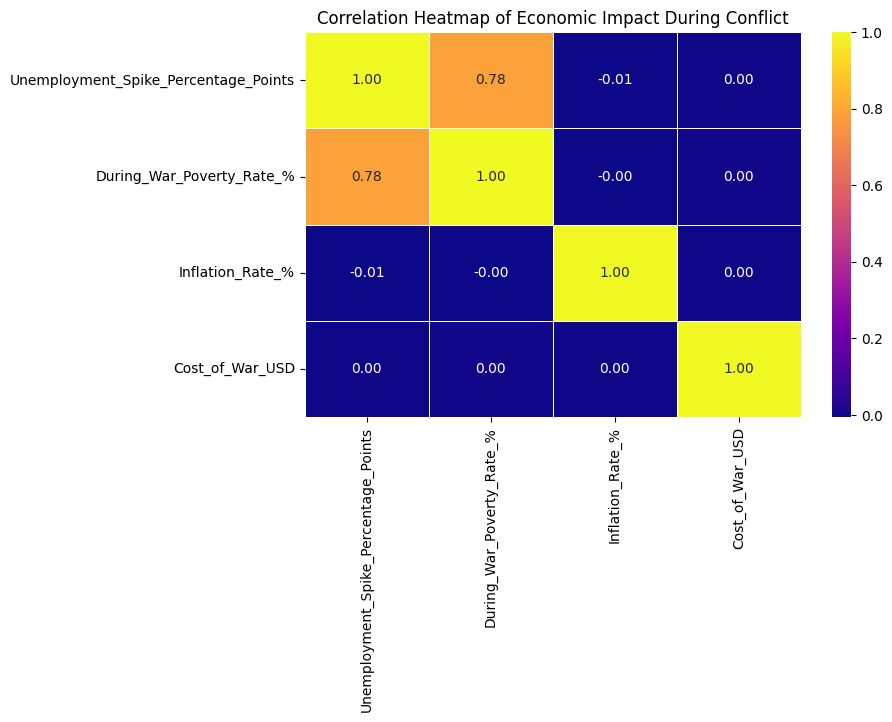

In [130]:
plt.figure(figsize = (8,5))
corr_data = df[['Unemployment_Spike_Percentage_Points', 
                'During_War_Poverty_Rate_%',
                'Inflation_Rate_%',
                'Cost_of_War_USD'
    ]]
correlation_matrix = corr_data.corr()

sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = 'plasma',
    fmt = '.2f',
    linewidth = 0.5
)
plt.title('Correlation Heatmap of Economic Impact During Conflict')
plt.show()

In [131]:
#df.head(1)

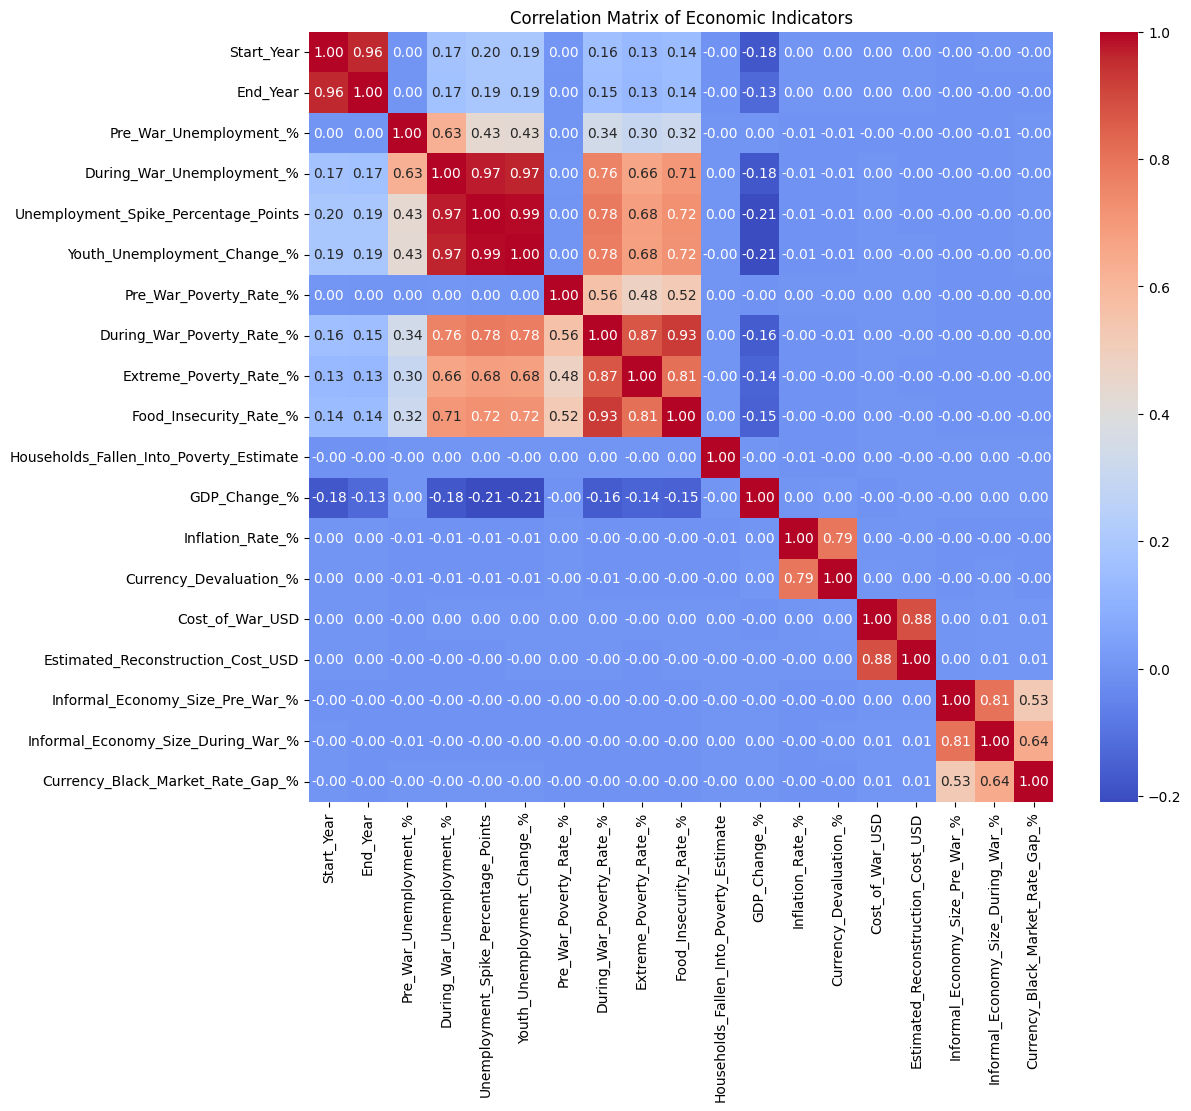

In [132]:
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Economic Indicators')
plt.show()

In [133]:
df.dtypes

Conflict_Name                               object
Conflict_Type                               object
Region                                      object
Start_Year                                   int64
End_Year                                     int64
Status                                      object
Primary_Country                             object
Pre_War_Unemployment_%                     float64
During_War_Unemployment_%                  float64
Unemployment_Spike_Percentage_Points       float64
Most_Affected_Sector                        object
Youth_Unemployment_Change_%                float64
Pre_War_Poverty_Rate_%                     float64
During_War_Poverty_Rate_%                  float64
Extreme_Poverty_Rate_%                     float64
Food_Insecurity_Rate_%                     float64
Households_Fallen_Into_Poverty_Estimate      int64
GDP_Change_%                               float64
Inflation_Rate_%                           float64
Currency_Devaluation_%         

**Question 4:** Plot a scatter plot comparing Pre_War_Unemployment_% (x-axis) and During_War_Unemployment_% (y-axis). Include a regression line to show the general trend of unemployment spikes.

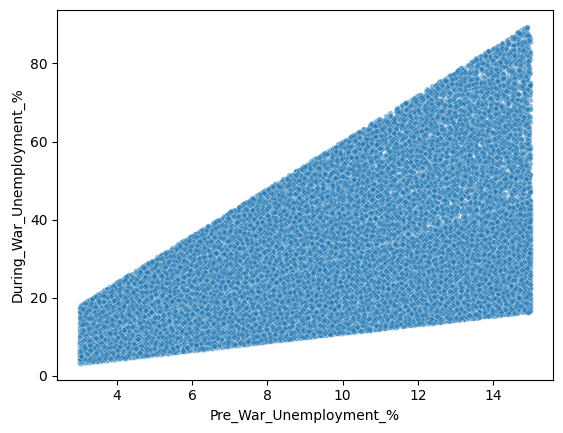

In [146]:
sns.scatterplot(
    data = df,
    x = 'Pre_War_Unemployment_%',
    y = 'During_War_Unemployment_%',
    s = 15,
    alpha = 0.5
)
plt.show()

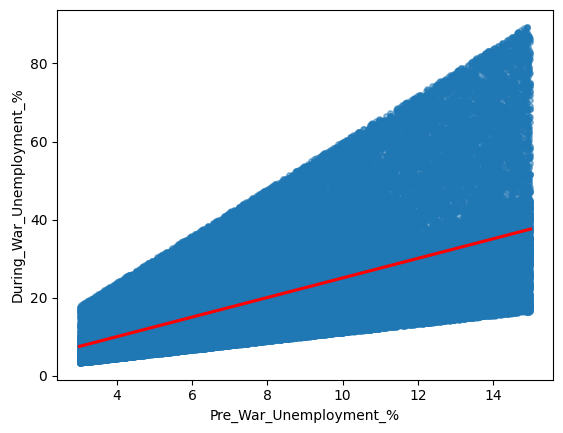

In [148]:
sns.regplot(
    data = df,
    x = 'Pre_War_Unemployment_%',
    y = 'During_War_Unemployment_%',
    line_kws={'color':'red'},
    scatter_kws={'s':15, 'alpha':0.5}
)
plt.show()

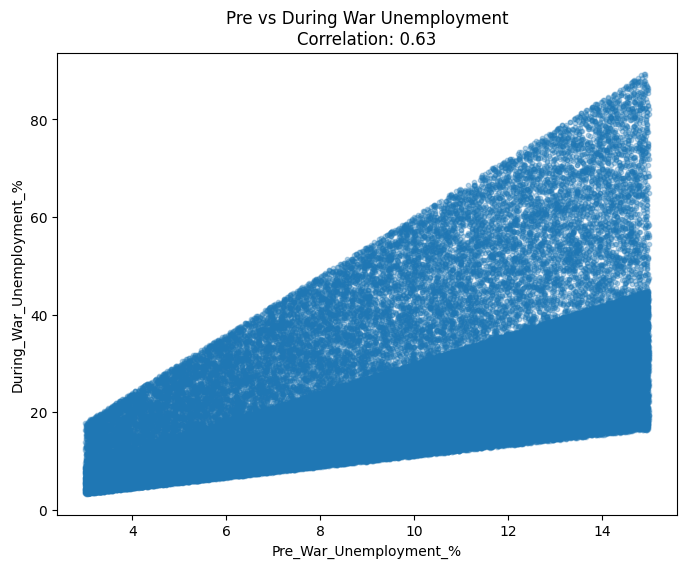

In [149]:
corr = df['Pre_War_Unemployment_%'].corr(df['During_War_Unemployment_%'])

plt.figure(figsize=(8,6))

sns.regplot(
    data=df,
    x='Pre_War_Unemployment_%',
    y='During_War_Unemployment_%',
    scatter_kws={'s':10, 'alpha':0.3}
)

plt.title(f'Pre vs During War Unemployment\nCorrelation: {corr:.2f}')
plt.show()

**Question 5:** Use a count plot to identify which Most_Affected_Sector is most frequently reported across the dataset.

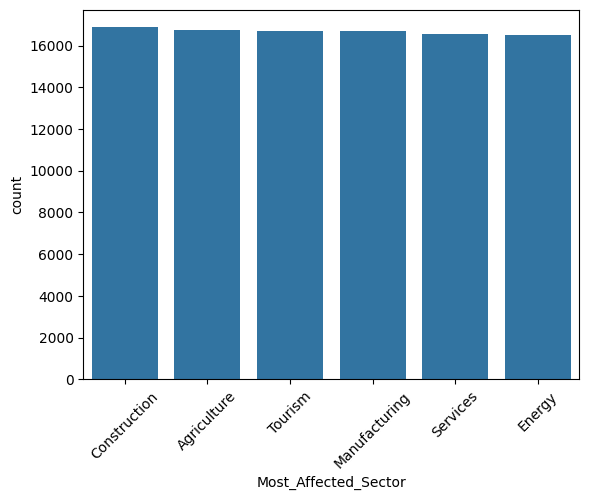

In [152]:
sns.countplot(
    data = df,
    x = 'Most_Affected_Sector', 
    order=df['Most_Affected_Sector'].value_counts().index
)
plt.xticks(rotation=45)
plt.show()

**Question 6:** Compare the distribution of Currency_Devaluation_% across different Black_Market_Activity_Level categories (High, Moderate, Low, etc.) using box plots.

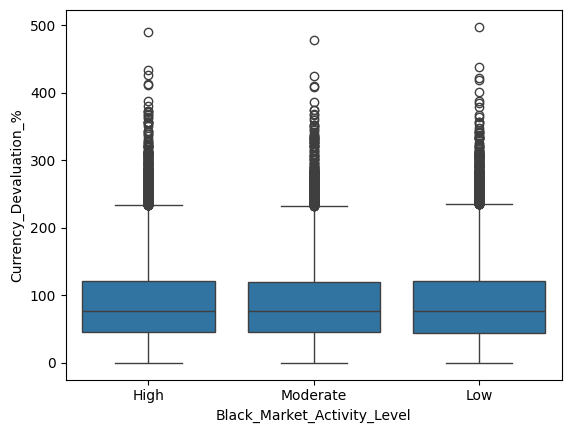

In [155]:
sns.boxplot(
    data = df,
    x = 'Black_Market_Activity_Level',
    y = 'Currency_Devaluation_%',
    order=['High', 'Moderate', 'Low']
)
plt.show()

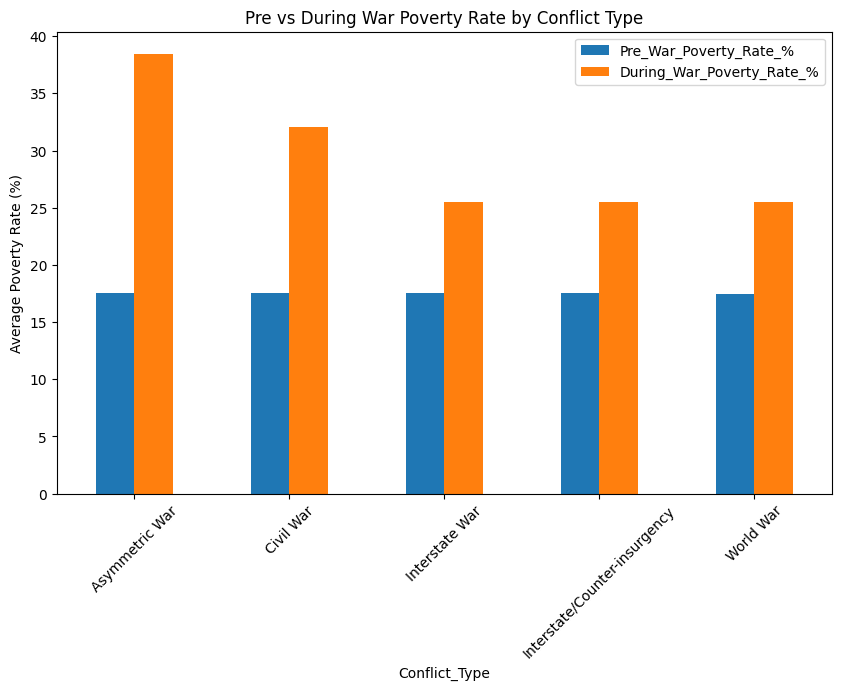

In [167]:
poverty_avg = df.groupby('Conflict_Type')[[
    'Pre_War_Poverty_Rate_%',
    'During_War_Poverty_Rate_%'
]].mean()

poverty_avg.plot(kind='bar', figsize=(10,6))

plt.ylabel('Average Poverty Rate (%)')
plt.title('Pre vs During War Poverty Rate by Conflict Type')

plt.xticks(rotation=45)
plt.show()

**Question 7:** Plot a grouped bar chart comparing the average Pre_War_Poverty_Rate_% and During_War_Poverty_Rate_% for each Conflict_Type.

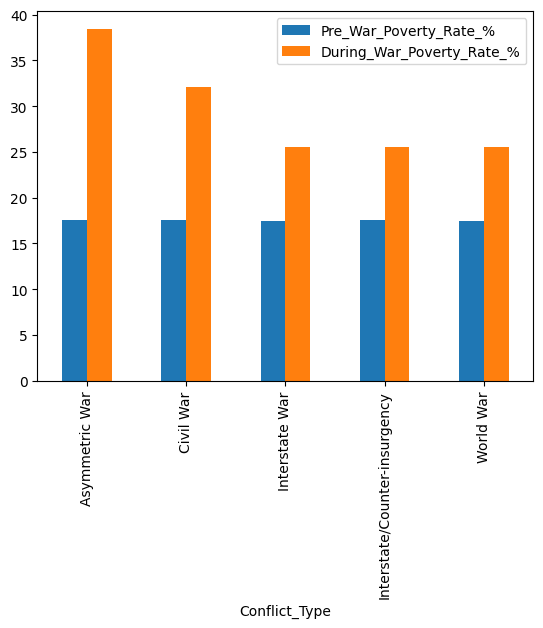

In [172]:
avg_Poverty = df.groupby('Conflict_Type')[['Pre_War_Poverty_Rate_%','During_War_Poverty_Rate_%']].mean().reset_index()
poverty_avg.plot(kind='bar')
plt.show()

In [171]:
df['Conflict_Type'].unique()

array(['World War', 'Asymmetric War', 'Civil War',
       'Interstate/Counter-insurgency', 'Interstate War'], dtype=object)

In [175]:
profiteering_counts = df['War_Profiteering_Documented'].value_counts()

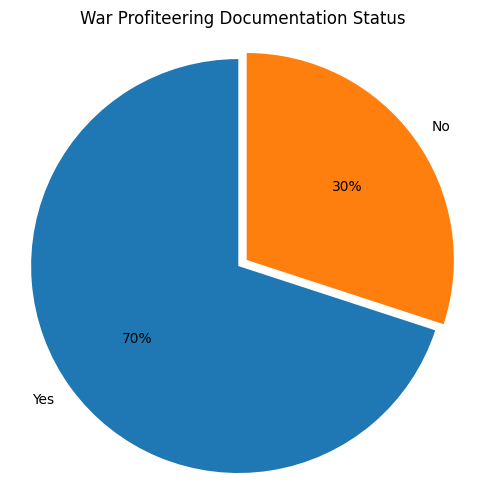

In [178]:
plt.figure(figsize=(6,6))

plt.pie(
    profiteering_counts,
    labels=profiteering_counts.index,
    autopct='%1.f%%',
    startangle=90,
    explode=[0.05, 0]  # first slice thoda highlight
)

plt.title('War Profiteering Documentation Status')
plt.axis('equal')  # Perfect circle
plt.show()

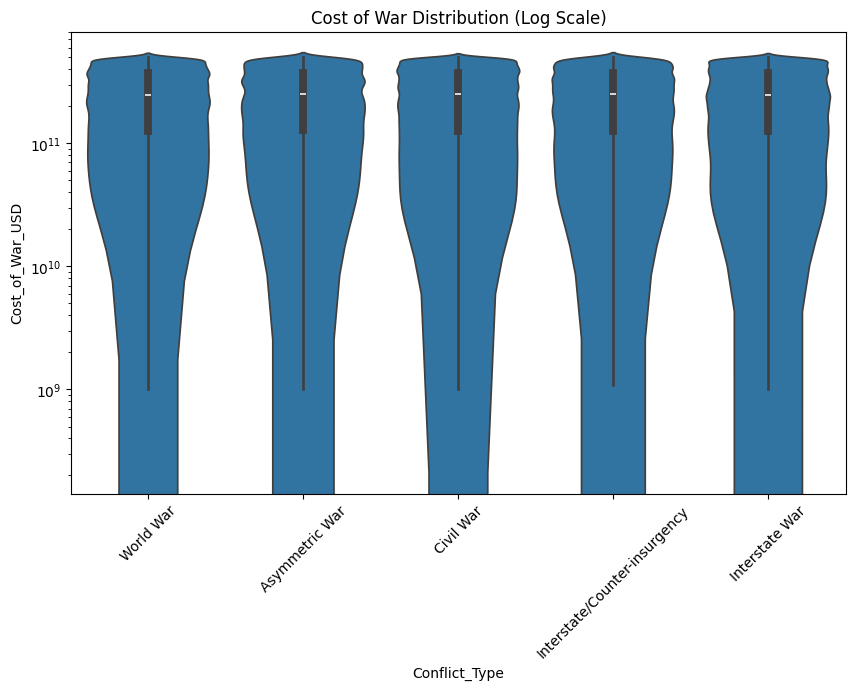

In [182]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='Conflict_Type',
    y='Cost_of_War_USD',
    inner='box'
)

plt.yscale('log')
plt.xticks(rotation=45)
plt.title('Cost of War Distribution (Log Scale)')
plt.show()

**Question 10:** Create a line plot showing the average Extreme_Poverty_Rate_% over the years based on the Start_Year of the conflicts

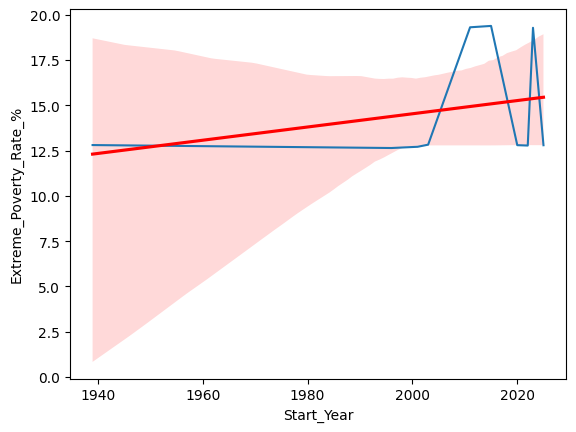

In [188]:
avg_Poverty_Rate = df.groupby('Start_Year')['Extreme_Poverty_Rate_%'].mean().reset_index().sort_values('Start_Year')  

sns.lineplot(
    data = avg_Poverty_Rate,
    x = 'Start_Year',
    y = 'Extreme_Poverty_Rate_%'
)
sns.regplot(
    data=avg_Poverty_Rate,
    x='Start_Year',
    y='Extreme_Poverty_Rate_%',
    scatter=False,
    color='red'
)
plt.show()

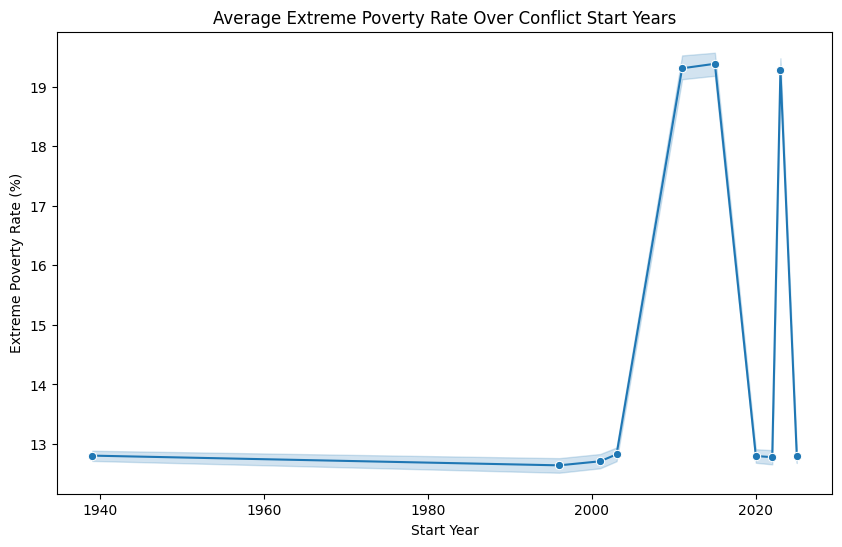

In [197]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=df,
    x='Start_Year',
    y='Extreme_Poverty_Rate_%',
    estimator='mean',
    errorbar=('ci', 95),   # 50% confidence interval
    marker='o'
)

plt.title('Average Extreme Poverty Rate Over Conflict Start Years')
plt.xlabel('Start Year')
plt.ylabel('Extreme Poverty Rate (%)')

plt.show()

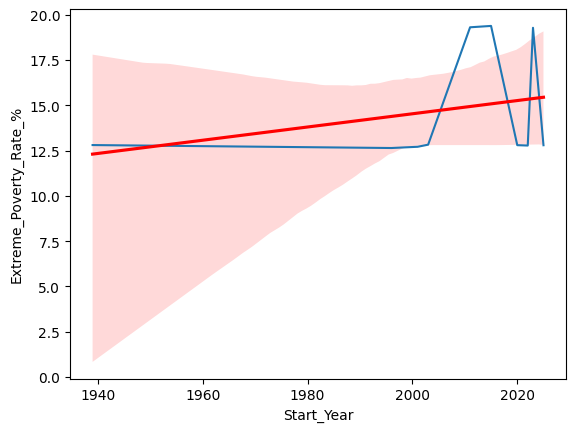

In [190]:
sns.lineplot(
    data=avg_Poverty_Rate,
    x='Start_Year',
    y='Extreme_Poverty_Rate_%'
)

sns.regplot(
    data=avg_Poverty_Rate,
    x='Start_Year',
    y='Extreme_Poverty_Rate_%',
    scatter=False,
    color='red'
)
plt.show()

Que 1. Har saal (Start_Year) ke liye Cost_of_War_USD ka cumulative total dikhao.

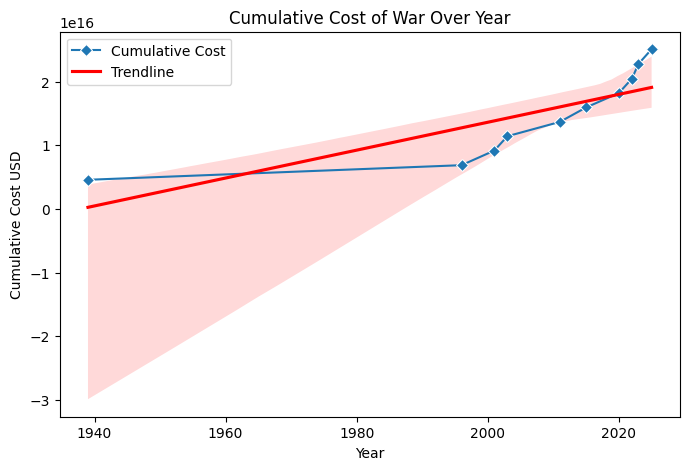

In [231]:
total_cost_of_war_usd = df.groupby('Start_Year')['Cost_of_War_USD'].sum().reset_index()
total_cost_of_war_usd['Cumulative_Cost_USD'] = total_cost_of_war_usd['Cost_of_War_USD'].cumsum()

plt.figure(figsize = (8,5))
sns.lineplot(
    data = total_cost_of_war_usd,
    x = "Start_Year",
    y = "Cumulative_Cost_USD",
    marker = "D",
    label = 'Cumulative Cost'
)

sns.regplot(
    data = total_cost_of_war_usd,
    x = "Start_Year",
    y = "Cumulative_Cost_USD",
    scatter=False,
    color='red',
    label = 'Trendline'
)
plt.title('Cumulative Cost of War Over Year')
plt.xlabel('Year')
plt.ylabel('Cumulative Cost USD')
plt.legend()
plt.show()

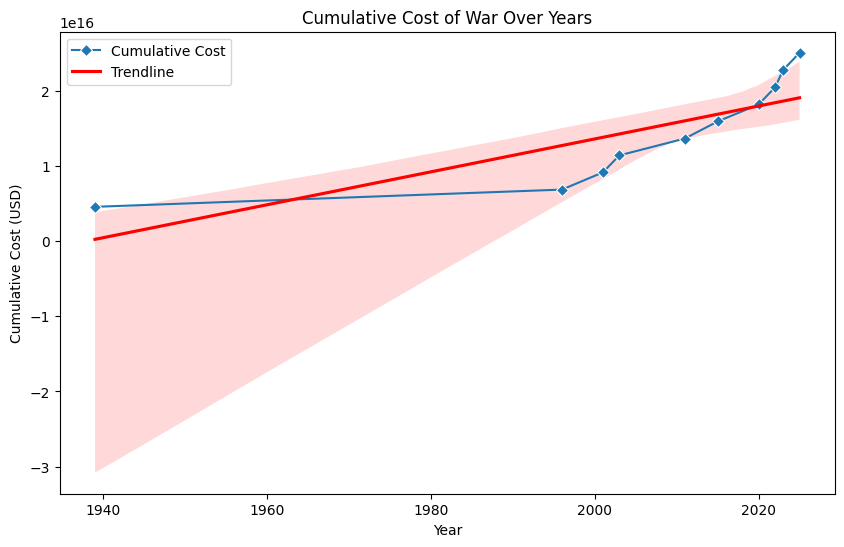

In [223]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Year-wise total
total_cost_of_war_usd = df.groupby('Start_Year')['Cost_of_War_USD'].sum().reset_index()

# Step 2: Cumulative total
total_cost_of_war_usd['Cumulative_Cost_USD'] = total_cost_of_war_usd['Cost_of_War_USD'].cumsum()

# Step 3: Plot
plt.figure(figsize=(10,6))

sns.lineplot(
    data = total_cost_of_war_usd,
    x = "Start_Year",
    y = "Cumulative_Cost_USD",
    marker = "D",
    label='Cumulative Cost'
)

sns.regplot(
    data = total_cost_of_war_usd,
    x = "Start_Year",
    y = "Cumulative_Cost_USD",
    scatter=False,
    color='red',
    label='Trendline'
)

plt.title("Cumulative Cost of War Over Years")
plt.ylabel("Cumulative Cost (USD)")
plt.xlabel("Year")
plt.legend()
plt.show()

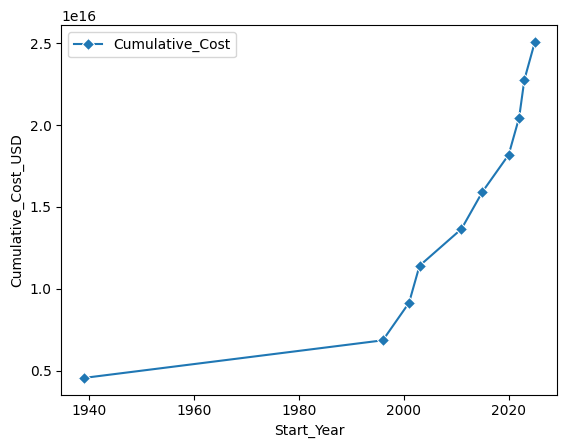

In [227]:
total_cost_of_war_usd = df.groupby('Start_Year')['Cost_of_War_USD'].sum().reset_index()
total_cost_of_war_usd['Cumulative_Cost_USD'] = total_cost_of_war_usd['Cost_of_War_USD'].cumsum()

sns.lineplot(
    data = total_cost_of_war_usd,
    x = "Start_Year",
    y = "Cumulative_Cost_USD",
    marker = "D",
    label = 'Cumulative_Cost'
)
plt.show()

**Que2.** Inflation_Rate_% during war ka yearly trend har region ke liye plot karo.

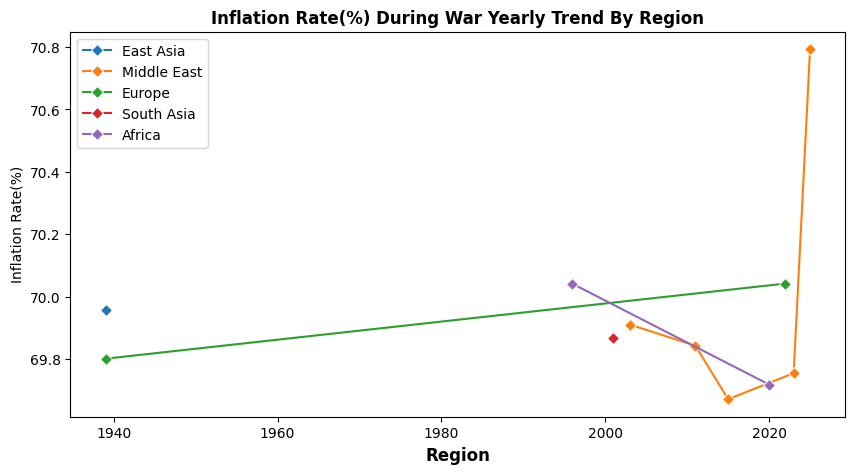

In [253]:
plt.figure(figsize = (10,5))

sns.lineplot(
    data = df,
    x = 'Start_Year',
    y = 'Inflation_Rate_%',
    marker = 'D',
    hue = 'Region',
    errorbar = None
)
plt.xlabel('Region', fontsize = 12,fontweight = 'bold' )
plt.ylabel('Inflation Rate(%)')
plt.title('Inflation Rate(%) During War Yearly Trend By Region', fontweight = 'bold')
plt.legend()
plt.show()

In [235]:
df.head(1)

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,Most_Affected_Sector,Youth_Unemployment_Change_%,Pre_War_Poverty_Rate_%,During_War_Poverty_Rate_%,Extreme_Poverty_Rate_%,Food_Insecurity_Rate_%,Households_Fallen_Into_Poverty_Estimate,GDP_Change_%,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented
0,WWII (Japan),World War,East Asia,1939,1945,Resolved,Japan,7.49,21.78,14.29,Construction,19.9,19.97,28.67,10.39,15.0,38487,-36.86,97.41,170.33,1.069570e+11,2.090550e+11,15.5,27.09,High,food,10.5,No


**Que 3.** Unemployment rate change ko war period aur post-war period ke liye line chart me dikhao.

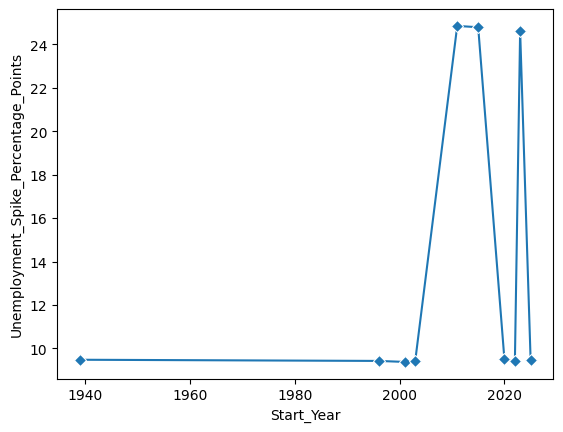

In [258]:
sns.lineplot(
    data = df,
    x = 'Start_Year',
    y = 'Unemployment_Spike_Percentage_Points',
    #hue = 'Period',
    marker = 'D',
    errorbar = None
)
plt.show()

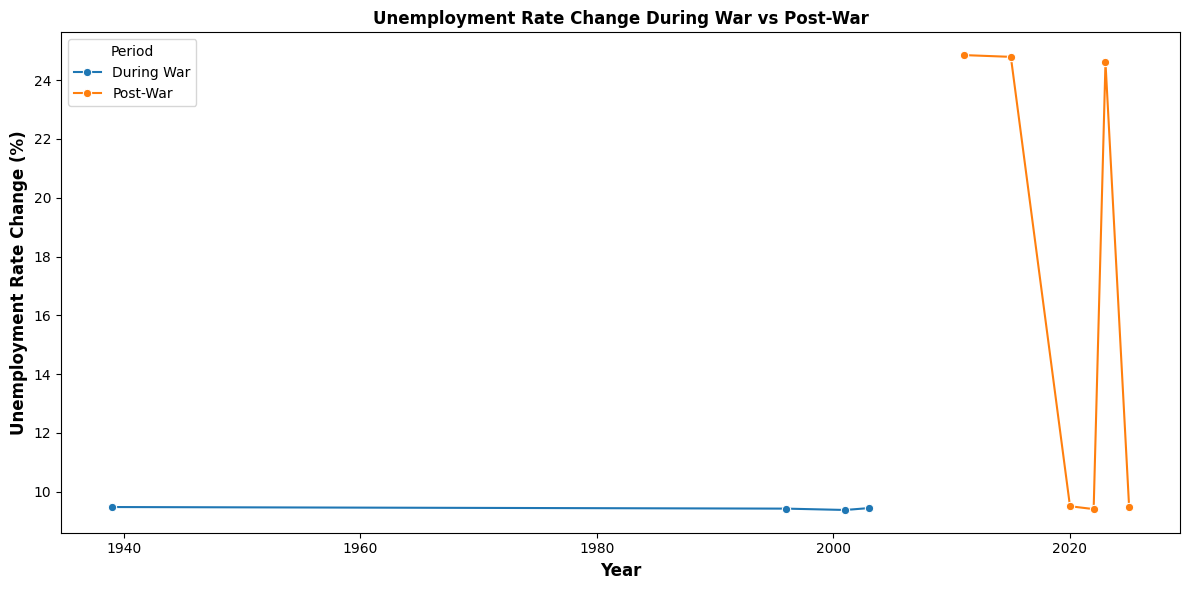

In [261]:
# Assume aapke paas 'Start_Year' aur 'War_End_Year' columns hain
# Agar War_End_Year nahi hai, manually set kar sakte hain, e.g., 2010

#War_End_Year = 2010  # example

# Period column create karen
df['Period'] = df['Start_Year'].apply(lambda x: 'During War' if x <= War_End_Year else 'Post-War')

# Fir line plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.lineplot(
    data=df,
    x='Start_Year',
    y='Unemployment_Spike_Percentage_Points',
    hue='Period',
    marker='o',
    errorbar=None
)

plt.xlabel('Year', fontsize=12, fontweight='bold')
plt.ylabel('Unemployment Rate Change (%)', fontsize=12, fontweight='bold')
plt.title('Unemployment Rate Change During War vs Post-War', fontweight='bold')
plt.legend(title='Period')
plt.tight_layout()
plt.show()

**Que4.** Average Extreme_Poverty_Rate_% ka year-wise line plot banao.

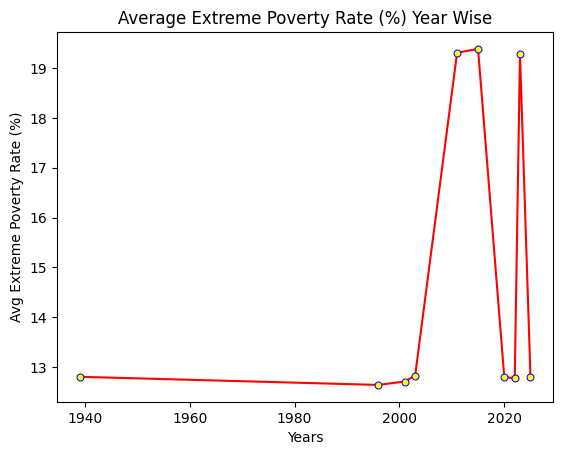

In [270]:
Avg_Extreme_Poverty_Rate = df.groupby('Start_Year')['Extreme_Poverty_Rate_%'].mean().reset_index()

sns.lineplot(
    data = Avg_Extreme_Poverty_Rate,
    x = 'Start_Year',
    y = 'Extreme_Poverty_Rate_%',
    errorbar = None,
    marker = 'o',
    color = 'red',
    markeredgecolor = 'blue',
    markerfacecolor = 'yellow',
    markersize = 5
)
plt.title('Average Extreme Poverty Rate (%) Year Wise')
plt.xlabel('Years')
plt.ylabel('Avg Extreme Poverty Rate (%)')
plt.show()

**Que 5**.Currency_Black_Market_Rate_Gap_% ka distribution dikhao, categorize karo by War_Profiteering_Documented (Yes/No).

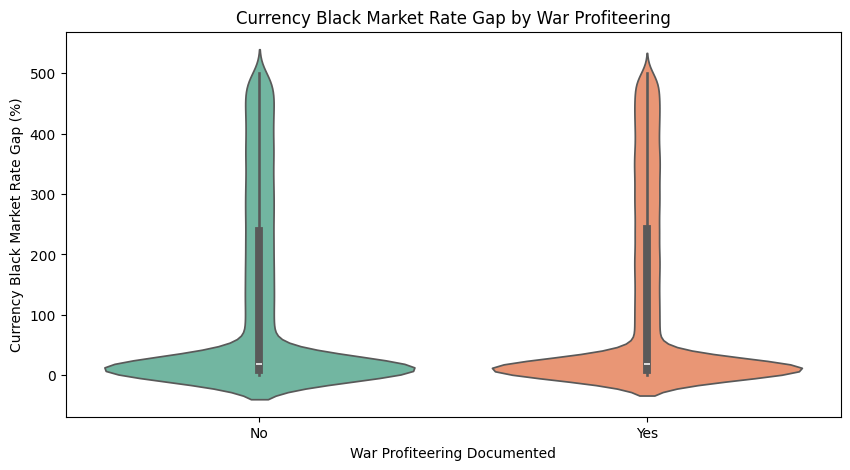

In [282]:
plt.figure(figsize = (10,5))
sns.violinplot(
    data = df,
    x = 'War_Profiteering_Documented',
    y = 'Currency_Black_Market_Rate_Gap_%',
    inner = 'box',
    palette = 'Set2',
    hue = 'War_Profiteering_Documented'
)
plt.title('Currency Black Market Rate Gap by War Profiteering')
plt.xlabel('War Profiteering Documented')
plt.ylabel('Currency Black Market Rate Gap (%)')
plt.show()

**Que6**.Household_Livelihood_Disruption_Score ko region-wise compare karo.

**Que7**. Military Expenditure vs Reconstruction Cost ka comparison region-wise stacked bar chart me dikhao.

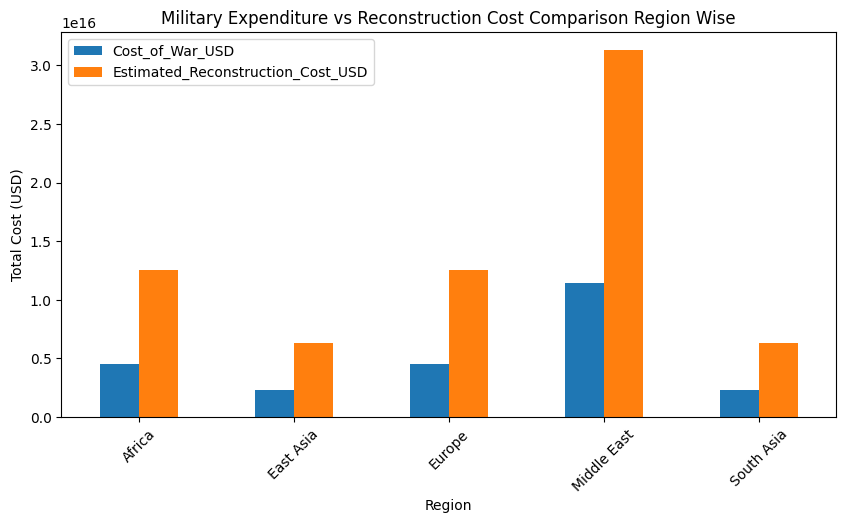

In [303]:

region_cost = df.groupby('Region')[['Cost_of_War_USD','Estimated_Reconstruction_Cost_USD']].sum().reset_index()

region_cost.plot(
    kind = 'bar',
    x = 'Region',
    y = ['Cost_of_War_USD','Estimated_Reconstruction_Cost_USD'],
    stacked=False,
    figsize = (10,5)
)
plt.title('Military Expenditure vs Reconstruction Cost Comparison Region Wise')
plt.xlabel('Region')
plt.ylabel('Total Cost (USD)')
plt.xticks(rotation=45)
plt.show()

**Que8** GDP Change During War (%) ka histogram banao to dekho spread aur skewness.

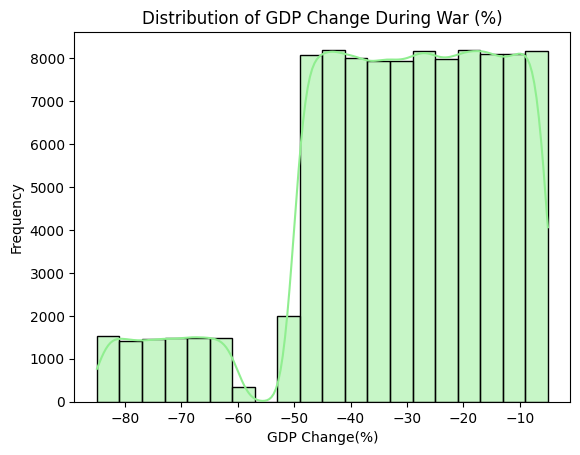

Skewness of GDP Change During War (%): -0.83


In [316]:
sns.histplot(
    data = df,
    x = 'GDP_Change_%',
    bins = 20,
    kde = True, 
    color='lightgreen'
)
plt.title('Distribution of GDP Change During War (%)')
plt.xlabel('GDP Change(%)')
plt.ylabel('Frequency')
plt.show()
gdp_skewness = skew(df['GDP_Change_%'].dropna())
print(f"Skewness of GDP Change During War (%): {gdp_skewness:.2f}")

In [315]:
from scipy.stats import skew
gdp_skewness = skew(df['GDP_Change_%'].dropna())
print(f"Skewness of GDP Change During War (%): {gdp_skewness:.2f}")

Skewness of GDP Change During War (%): -0.83


**Ques9**: Total War Cost aur Reconstruction Cost ka ratio per region dikhao (stacked bar chart).

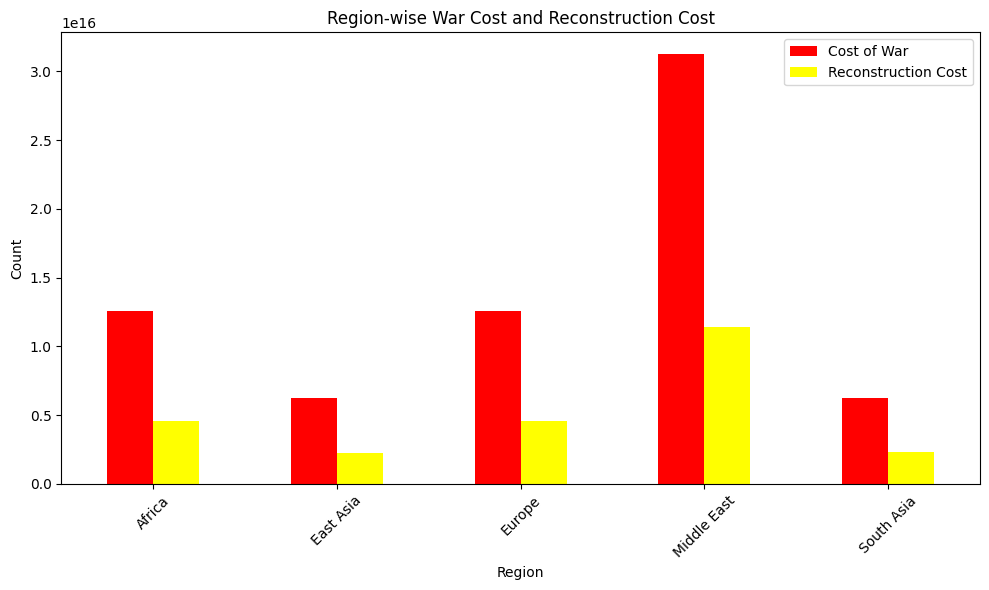

In [330]:
region_cost = df.groupby('Region')[['Estimated_Reconstruction_Cost_USD','Cost_of_War_USD']].sum().reset_index()
region_cost.plot(
    kind = 'bar',
    x = 'Region',
    y = ['Estimated_Reconstruction_Cost_USD','Cost_of_War_USD'],
    stacked = False,
    color = ['red','yellow'],
    figsize = (10,6),
    #lable = ['Estimated_Reconstruction_Cost_USD','Cost_of_War_USD']
)
plt.legend(['Cost of War', 'Reconstruction Cost'])
plt.title('Region-wise War Cost and Reconstruction Cost')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [317]:
df.head(1)

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,Most_Affected_Sector,Youth_Unemployment_Change_%,Pre_War_Poverty_Rate_%,During_War_Poverty_Rate_%,Extreme_Poverty_Rate_%,Food_Insecurity_Rate_%,Households_Fallen_Into_Poverty_Estimate,GDP_Change_%,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented,Period
0,WWII (Japan),World War,East Asia,1939,1945,Resolved,Japan,7.49,21.78,14.29,Construction,19.9,19.97,28.67,10.39,15.0,38487,-36.86,97.41,170.33,1.069570e+11,2.090550e+11,15.5,27.09,High,food,10.5,No,During War


**Ques 10**.Percentage of population displaced ko region-wise pie chart me dikhayein

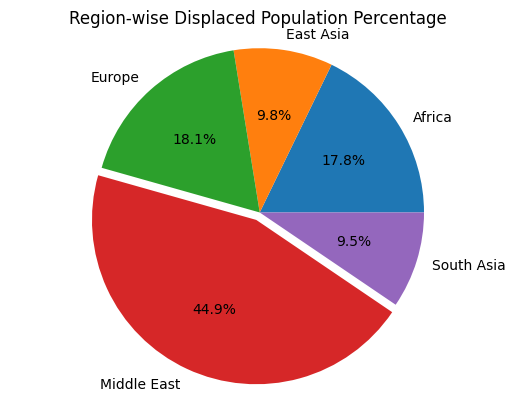

In [339]:
region_displaced = df.groupby('Region')['Households_Fallen_Into_Poverty_Estimate'].sum()
explode = [0.00,0.00,0.00,0.05,0.00]
plt.pie(
    region_displaced,
    labels = region_displaced.index,
    autopct = '%1.1f%%',
    explode = explode
)
plt.title('Region-wise Displaced Population Percentage')
plt.axis('equal')
plt.show()

In [340]:
df.head(1)

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,Most_Affected_Sector,Youth_Unemployment_Change_%,Pre_War_Poverty_Rate_%,During_War_Poverty_Rate_%,Extreme_Poverty_Rate_%,Food_Insecurity_Rate_%,Households_Fallen_Into_Poverty_Estimate,GDP_Change_%,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented,Period
0,WWII (Japan),World War,East Asia,1939,1945,Resolved,Japan,7.49,21.78,14.29,Construction,19.9,19.97,28.67,10.39,15.0,38487,-36.86,97.41,170.33,1.069570e+11,2.090550e+11,15.5,27.09,High,food,10.5,No,During War


**Ques 11.** Aid Received vs Estimated Need ka bar chart with grouped bars per country/region

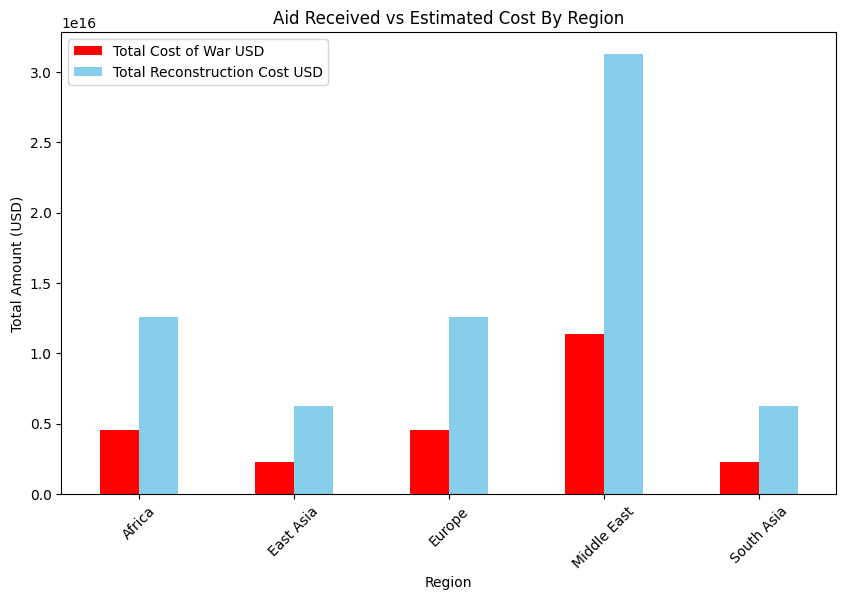

In [349]:
region_data = df.groupby('Region')[['Cost_of_War_USD','Estimated_Reconstruction_Cost_USD']].sum().reset_index()

region_data.plot(
    kind ='bar',
    x = 'Region',
    y = ['Cost_of_War_USD','Estimated_Reconstruction_Cost_USD'],
    stacked = False,
    color = ['red','skyblue'],
    figsize = (10,6)
)
plt.legend(['Total Cost of War USD', 'Total Reconstruction Cost USD'])
plt.xticks(rotation = 45)
plt.ylabel('Total Amount (USD)')
plt.title('Aid Received vs Estimated Cost By Region')
plt.show()

**Ques12.** Inflation Rate vs Unemployment Spike ka scatter plot banao, line-of-best-fit (trendline) ke sath.

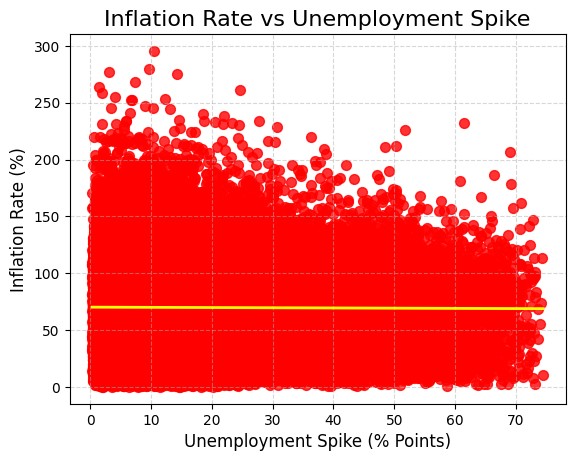

In [358]:
sns.regplot(
    data = df,
    x = 'Unemployment_Spike_Percentage_Points',
    y = 'Inflation_Rate_%',
    scatter_kws = {'color':'red', 's':50},
    line_kws = {'color': 'yellow', 'linewidth':2}
)
plt.title('Inflation Rate vs Unemployment Spike', fontsize=16)
plt.xlabel('Unemployment Spike (% Points)', fontsize=12)
plt.ylabel('Inflation Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [350]:
df.head(1)

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,Most_Affected_Sector,Youth_Unemployment_Change_%,Pre_War_Poverty_Rate_%,During_War_Poverty_Rate_%,Extreme_Poverty_Rate_%,Food_Insecurity_Rate_%,Households_Fallen_Into_Poverty_Estimate,GDP_Change_%,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented,Period
0,WWII (Japan),World War,East Asia,1939,1945,Resolved,Japan,7.49,21.78,14.29,Construction,19.9,19.97,28.67,10.39,15.0,38487,-36.86,97.41,170.33,1.069570e+11,2.090550e+11,15.5,27.09,High,food,10.5,No,During War


In [359]:
df.columns

Index(['Conflict_Name', 'Conflict_Type', 'Region', 'Start_Year', 'End_Year',
       'Status', 'Primary_Country', 'Pre_War_Unemployment_%',
       'During_War_Unemployment_%', 'Unemployment_Spike_Percentage_Points',
       'Most_Affected_Sector', 'Youth_Unemployment_Change_%',
       'Pre_War_Poverty_Rate_%', 'During_War_Poverty_Rate_%',
       'Extreme_Poverty_Rate_%', 'Food_Insecurity_Rate_%',
       'Households_Fallen_Into_Poverty_Estimate', 'GDP_Change_%',
       'Inflation_Rate_%', 'Currency_Devaluation_%', 'Cost_of_War_USD',
       'Estimated_Reconstruction_Cost_USD', 'Informal_Economy_Size_Pre_War_%',
       'Informal_Economy_Size_During_War_%', 'Black_Market_Activity_Level',
       'Primary_Black_Market_Goods', 'Currency_Black_Market_Rate_Gap_%',
       'War_Profiteering_Documented', 'Period'],
      dtype='object')

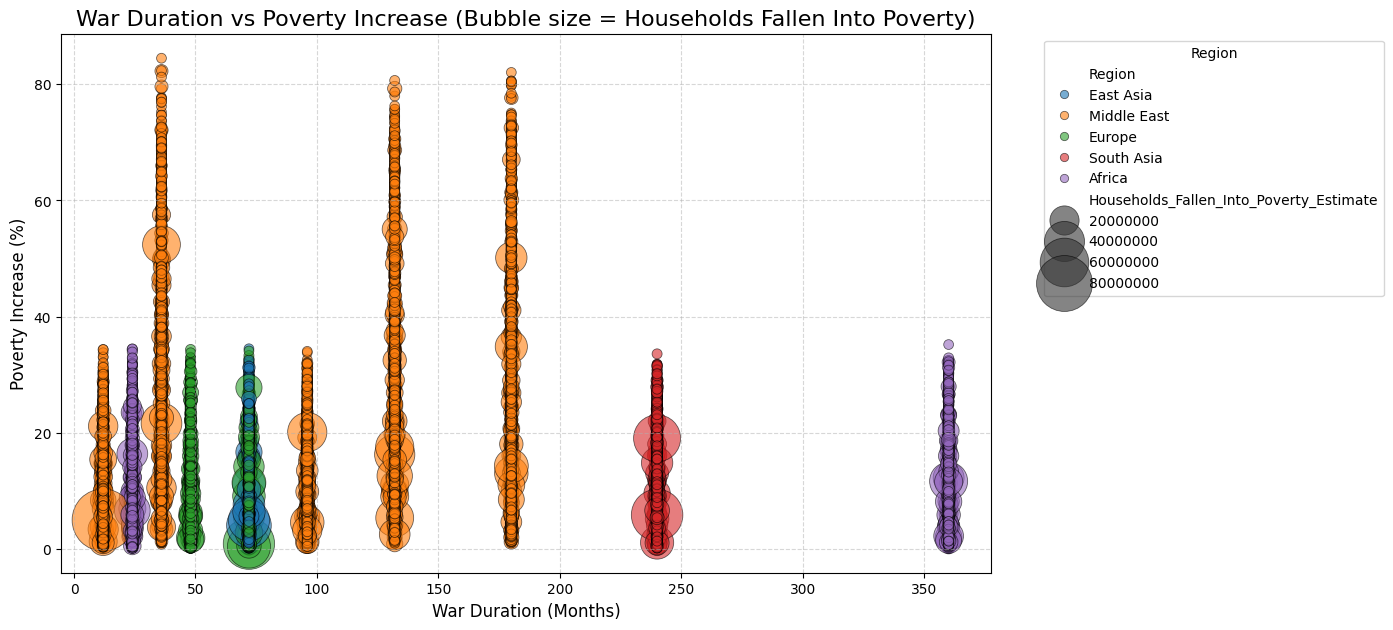

In [360]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Calculate derived columns
df['War_Duration_Months'] = (df['End_Year'] - df['Start_Year']) * 12
df['Poverty_Increase_%'] = df['During_War_Poverty_Rate_%'] - df['Pre_War_Poverty_Rate_%']

plt.figure(figsize=(12,7))

# Bubble plot
sns.scatterplot(
    data=df,
    x='War_Duration_Months',
    y='Poverty_Increase_%',
    size='Households_Fallen_Into_Poverty_Estimate',   # bubble size
    sizes=(50, 2000),
    hue='Region',                                     # optional color by region
    palette='tab10',
    alpha=0.6,
    edgecolor='black'
)

plt.title('War Duration vs Poverty Increase (Bubble size = Households Fallen Into Poverty)', fontsize=16)
plt.xlabel('War Duration (Months)', fontsize=12)
plt.ylabel('Poverty Increase (%)', fontsize=12)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


**Ques15.** Total War Cost by Conflict Type (civil war, international war, insurgency) – bar chart.

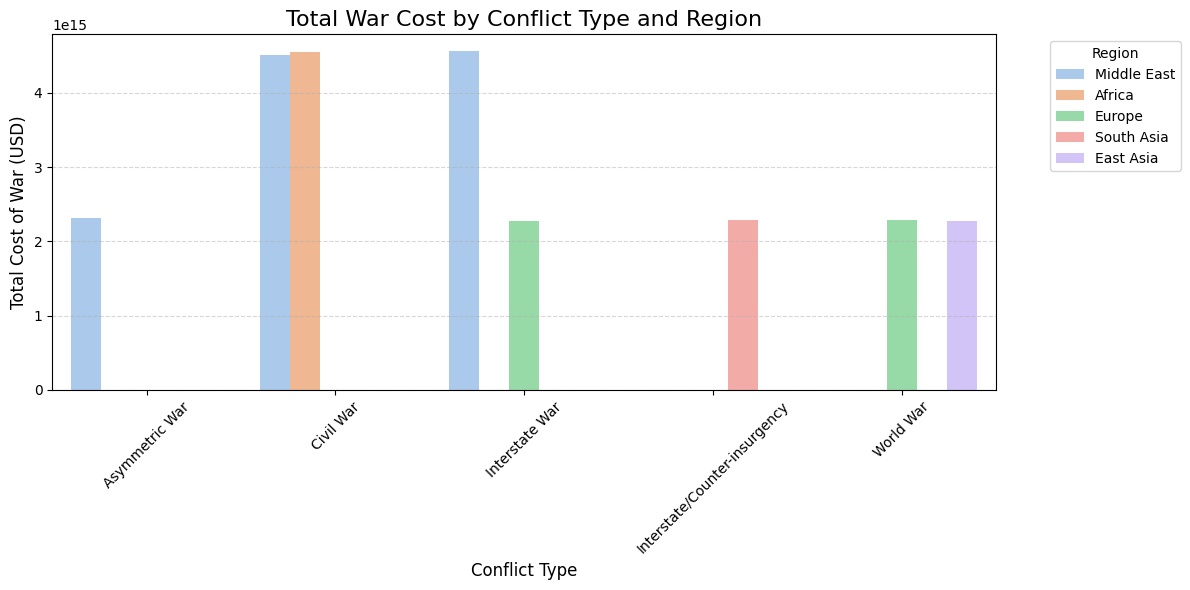

In [391]:
total_cost_by_type = df.groupby(['Conflict_Type','Region'])['Cost_of_War_USD'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.barplot(
    data = total_cost_by_type,
    x = 'Conflict_Type',
    y = 'Cost_of_War_USD',
    palette='pastel',
    hue = 'Region'
)
plt.title('Total War Cost by Conflict Type and Region', fontsize=16)
plt.xlabel('Conflict Type', fontsize=12)
plt.ylabel('Total Cost of War (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Region', bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Ques : Number of people losing livelihood vs Sector (Agriculture, Manufacturing, Services) – stacked bar chart.

In [393]:
df.head(1)

,Conflict_Name,Conflict_Type,Region,Start_Year,End_Year,Status,Primary_Country,Pre_War_Unemployment_%,During_War_Unemployment_%,Unemployment_Spike_Percentage_Points,Most_Affected_Sector,Youth_Unemployment_Change_%,Pre_War_Poverty_Rate_%,During_War_Poverty_Rate_%,Extreme_Poverty_Rate_%,Food_Insecurity_Rate_%,Households_Fallen_Into_Poverty_Estimate,GDP_Change_%,Inflation_Rate_%,Currency_Devaluation_%,Cost_of_War_USD,Estimated_Reconstruction_Cost_USD,Informal_Economy_Size_Pre_War_%,Informal_Economy_Size_During_War_%,Black_Market_Activity_Level,Primary_Black_Market_Goods,Currency_Black_Market_Rate_Gap_%,War_Profiteering_Documented,Period,War_Duration_Months,Poverty_Increase_%
0,WWII (Japan),World War,East Asia,1939,1945,Resolved,Japan,7.49,21.78,14.29,Construction,19.9,19.97,28.67,10.39,15.0,38487,-36.86,97.41,170.33,1.069570e+11,2.090550e+11,15.5,27.09,High,food,10.5,No,During War,72,8.7


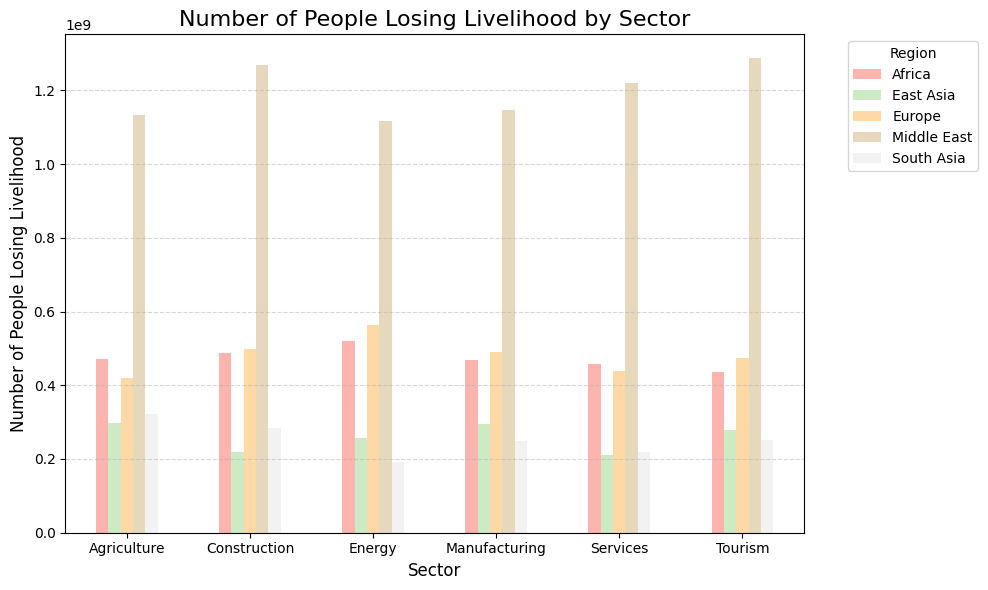

In [395]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Prepare data
# Pivot table: rows = Sector, columns = Conflict_Type (ya Region), values = total affected
livelihood_data = df.groupby(['Most_Affected_Sector', 'Region'])['Households_Fallen_Into_Poverty_Estimate'].sum().unstack(fill_value=0)

# Step 2: Plot stacked bar chart
livelihood_data.plot(
    kind='bar',
    stacked=False,
    figsize=(10,6),
    colormap='Pastel1'
)

plt.title('Number of People Losing Livelihood by Sector', fontsize=16)
plt.xlabel('Sector', fontsize=12)
plt.ylabel('Number of People Losing Livelihood', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Region', bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()